In [2]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

In [4]:
# 1. Memuat dataset dari Kaggle (Credit Card Fraud Detection)
data = pd.read_csv('creditcard.csv')

# Menampilkan 5 baris pertama dataset
print("5 Baris Pertama Dataset:")
print(data.head())

5 Baris Pertama Dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

       


Distribusi Kelas Target:
Class
0    284315
1       492
Name: count, dtype: int64

Proporsi Kelas Target:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


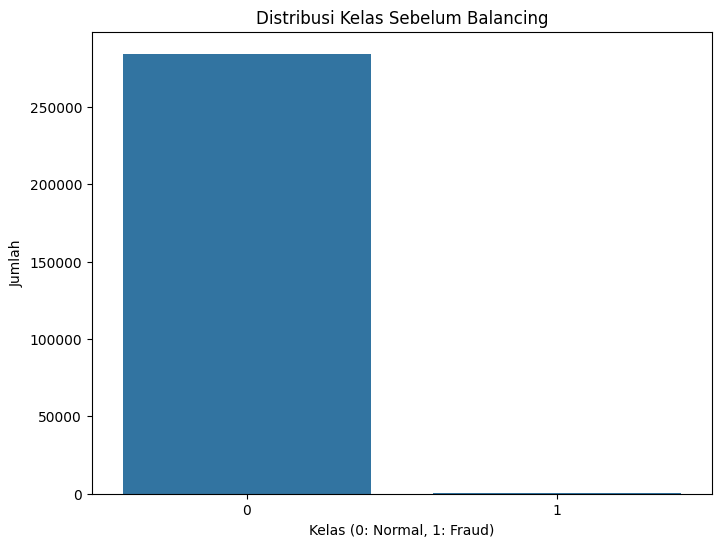

In [5]:
# 2. Eksplorasi Awal dan Pra-pemrosesan
# Analisis distribusi kelas target
print("\nDistribusi Kelas Target:")
print(data['Class'].value_counts())
print("\nProporsi Kelas Target:")
print(data['Class'].value_counts(normalize=True))

# Visualisasi distribusi kelas sebelum balancing (Bar Plot)
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=data)
plt.title('Distribusi Kelas Sebelum Balancing')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()

# Normalisasi fitur numerik dengan MinMaxScaler (kecuali kolom 'Class')
features = data.drop('Class', axis=1)
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)
X = pd.DataFrame(features_scaled, columns=features.columns)
y = data['Class']


Jumlah data sebelum balancing: Counter({0: 284315, 1: 492})


c:\Users\Voire\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Voire\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Voire\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Voire\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

Jumlah data sesudah balancing: Counter({0: 284315, 1: 284315})


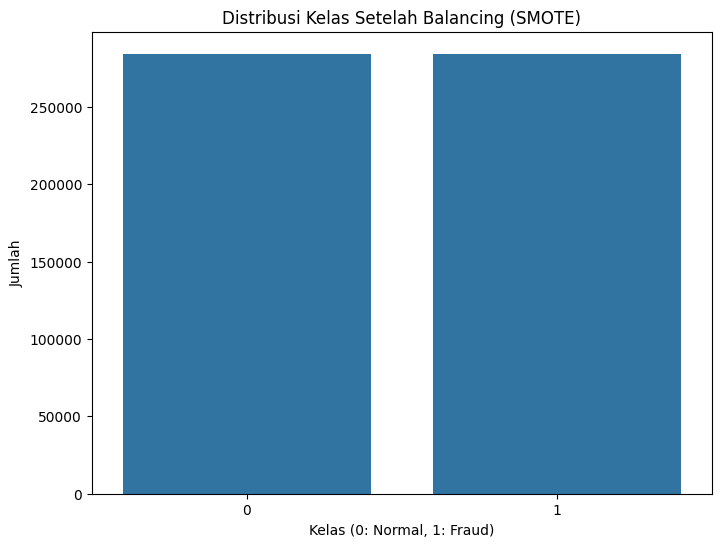

In [6]:
# 3. Data Balancing dengan SMOTE
# Sebelum balancing
print("\nJumlah data sebelum balancing:", Counter(y))

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Sesudah balancing
print("Jumlah data sesudah balancing:", Counter(y_balanced))

# Visualisasi distribusi kelas setelah balancing
plt.figure(figsize=(8, 6))
sns.countplot(x=y_balanced)
plt.title('Distribusi Kelas Setelah Balancing (SMOTE)')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()


Distribusi Kelas di Training Set:
Counter({0: 227452, 1: 227452})
Distribusi Kelas di Testing Set:
Counter({1: 56863, 0: 56863})


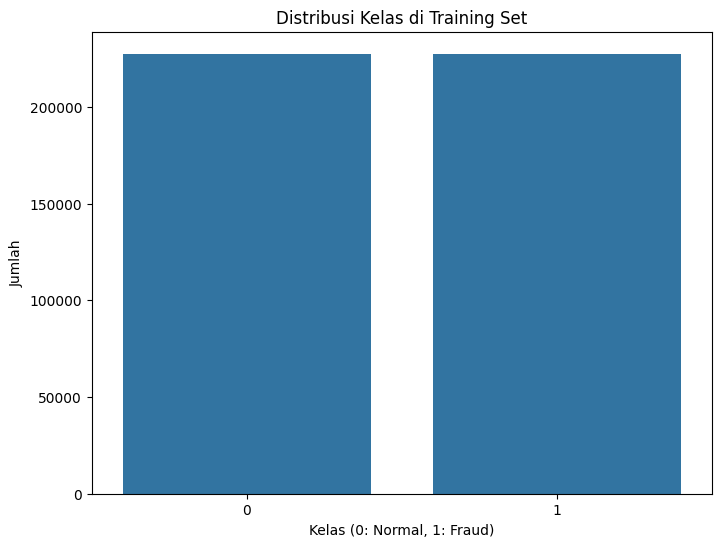

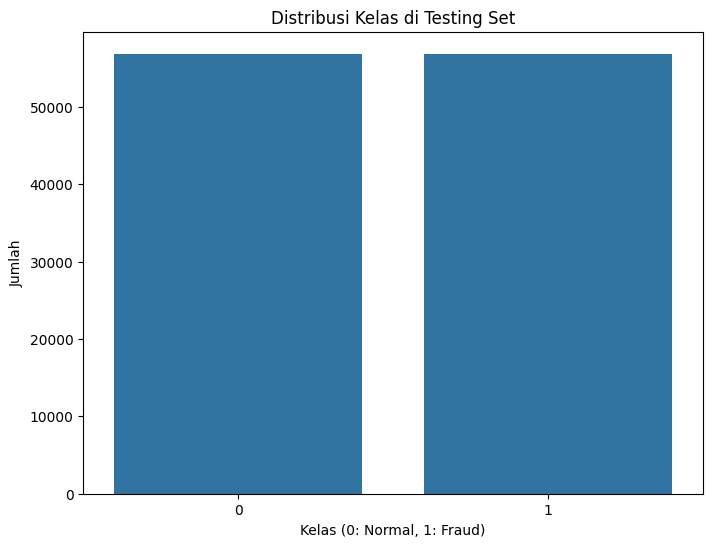

In [7]:
# 4. Data Splitting
# Split dataset menjadi training (80%) dan testing (20%) dengan stratify
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, 
                                                    test_size=0.2, 
                                                    stratify=y_balanced, 
                                                    random_state=42)

# Tampilkan distribusi kelas setelah splitting
print("\nDistribusi Kelas di Training Set:")
print(Counter(y_train))
print("Distribusi Kelas di Testing Set:")
print(Counter(y_test))

# Visualisasi distribusi kelas setelah splitting (Training Set)
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train)
plt.title('Distribusi Kelas di Training Set')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()

# Visualisasi distribusi kelas setelah splitting (Testing Set)
plt.figure(figsize=(8, 6))
sns.countplot(x=y_test)
plt.title('Distribusi Kelas di Testing Set')
plt.xlabel('Kelas (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah')
plt.show()